# Test scip simple

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import sys
import os


In [73]:
import Labber
from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.254"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

QICK library version mismatch: 0.2.302 remote (the board), 0.2.325 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_8f6a817f41684ae896303de4a116227d@192.168.10.254:37301
QICK running on ZCU216, software version 0.2.302

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	16 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 16384 samples (1.709 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 8192 samples (0.855 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 3 is

In [74]:
client = Labber.connectToServer('localhost', timeout=86400)
yoko_connect='0x0B21::0x0039::91WB18861'
yoko_global = client.connectToInstrument(
    'Yokogawa GS200 DC Source', dict(
        interface='USB', address=(yoko_connect))
)
yoko_global_cfg = {
    'Current - Sweep rate': 50e-6,
    'Function': 'Current',
    'Range (I)': '10 mA',
    'Output': True,
}
yoko_global.setValue(sQuant='Output', value=True)


True

In [75]:
Yoko_current = 5.95 # [mA]
yoko_global.setValue(sQuant='Current', value=Yoko_current*1e-3, rate=20e-6)

0.00595

In [126]:
QubitIndex = 0
from single_qubit_pyscrip_v1_1.system_cfg import hw_cfg, readout_cfg, qubit_cfg, expt_cfg
from single_qubit_pyscrip_v1_1.system_tool import select_config_idx, update_python_dict

config = {**hw_cfg, **readout_cfg, **qubit_cfg, **expt_cfg}
run_cfg = select_config_idx(config, idx=QubitIndex)

  0%|          | 0/1000 [00:00<?, ?it/s]

Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0508\s001_tof_Q0_5


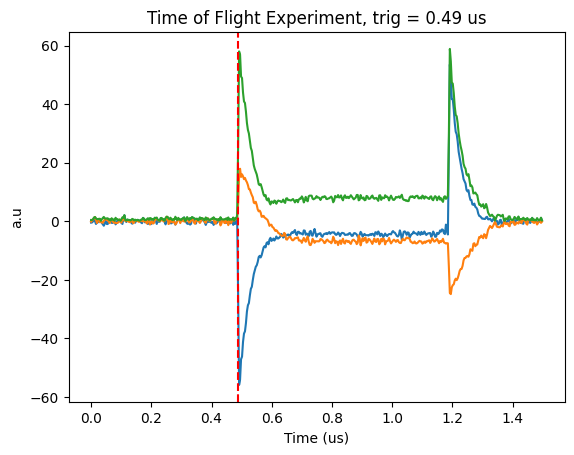

In [77]:
from single_qubit_pyscrip_v1_1.s001_time_of_flight import TOF
run_cfg.update({
    'res_gain_ge':1,
    'ro_length': 1.5,
    'res_length':0.7,
    'soft_avgs':1000
})

tof = TOF(soc, soccfg, run_cfg)
tof.run()
tof.plot()
tof.saveLabber(QubitIndex)

  0%|          | 0/50 [00:00<?, ?it/s]

Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0508\s002_onetone_Q0_25


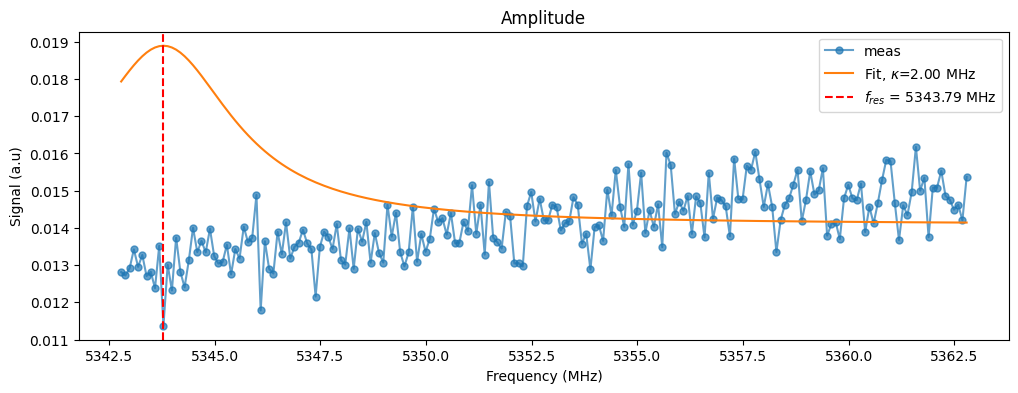

In [125]:
from single_qubit_pyscrip_v1_1.s002_res_spec_ge import Resonator_onetone
f_res = config['res_freq_ge'][QubitIndex]
run_cfg.update({
    'steps':201,
    'res_gain_ge':0.06,
    'res_freq_ge': f_res + QickSweep1D('freqloop', -10,10),
    'relax_delay': 1
})
onetone = Resonator_onetone(soc, soccfg, run_cfg)
onetone.run(py_avg = 50)
fit = onetone.plot()
run_cfg['res_freq_ge'] = round(fit)

onetone.saveLabber(QubitIndex)

  0%|          | 0/50 [00:00<?, ?it/s]

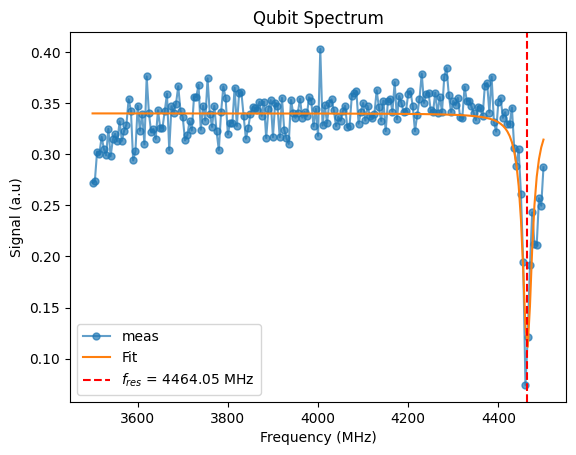

In [117]:
from single_qubit_pyscrip_v1_1.s003_qubit_spec_ge import Qubit_Twotone
run_cfg.update({
    'steps':201,
    'qubit_freq_ge': 2500 + QickSweep1D('freqloop', -500,+500),
    'qubit_gain_ge': 0.5,
    'qubit_length_ge': 5,
    'relax_delay':1
})
twotone = Qubit_Twotone(soc, soccfg, run_cfg)
twotone.run(py_avg = 50)
f_ge = twotone.plot()
run_cfg['qubit_freq_ge'] = f_ge

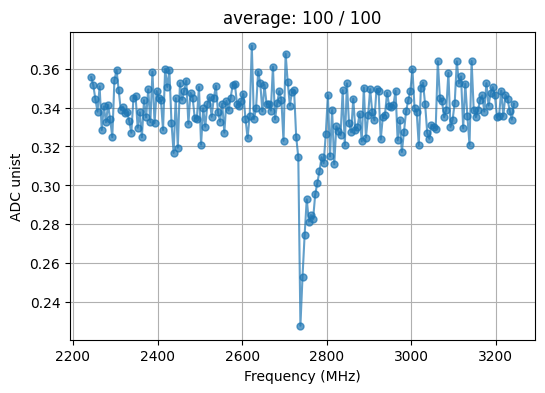

In [111]:
twotone.liveplot(100)

Time sweep:   0%|          | 0/51 [00:00<?, ?it/s]

Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0508\004_time_rabi_ge_Q0_4


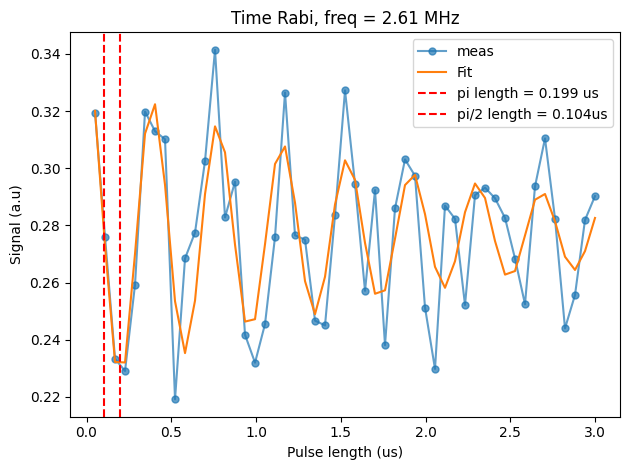

In [120]:
from single_qubit_pyscrip_v1_1.s004_time_rabi_ge import Time_Rabi

run_cfg.update({'qubit_gain_ge': 0.1, 'relax_delay': 30})

timerabi = Time_Rabi(soc, soccfg, run_cfg)
timerabi.run(50, 0.05, 3, 51)
timerabi.plot()
timerabi.saveLabber(QubitIndex)

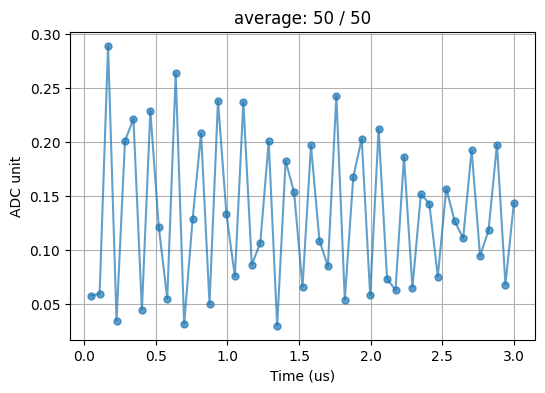

In [119]:
timerabi.liveplot(50, 0.05, 3, 51)

In [121]:
from single_qubit_pyscrip_v1_1.s005_power_rabi_ge import Amp_Rabi

run_cfg.update({
    'steps': 50,
    'qubit_gain_ge': QickSweep1D('gainloop', 0, 1),
    'sigma':0.15,
    'relax_delay': 100})

amprabi = Amp_Rabi(soc, soccfg, run_cfg)
# amprabi.run(100)
# run_cfg['qubit_pi_gain_ge'], run_cfg['qubit_pi2_gain_ge'] = amprabi.plot()

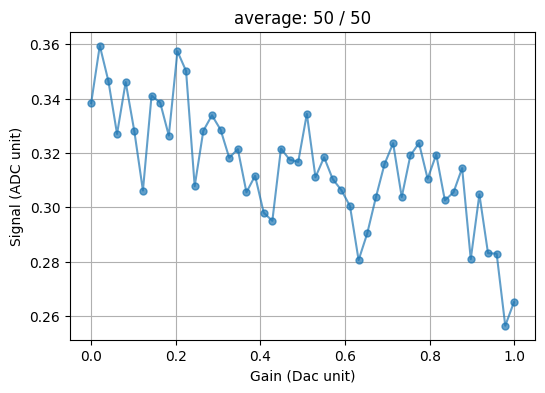

In [122]:
amprabi.liveplot(50)

  0%|          | 0/100 [00:00<?, ?it/s]

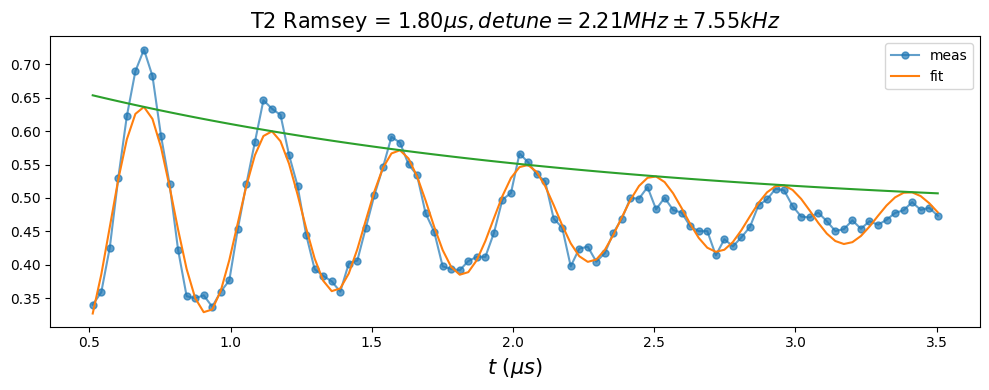

In [ ]:
from single_qubit_pyscrip_v1_1.s006_Ramsey_ge import Ramsey

run_cfg.update({
    'steps': 100,
    'wait_time': QickSweep1D('waitloop', 0, 3),
    'ramsey_freq': 2})

t2r = Ramsey(soc, soccfg, run_cfg)
t2r.run(100)
t2r.plot()
# t2r.saveLabber(QubitIndex)
# t2r.correct_detune()

In [46]:
# t2r.liveplot(50)

  0%|          | 0/50 [00:00<?, ?it/s]

Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0508\s007_SpinEcho_ge_Q0_1


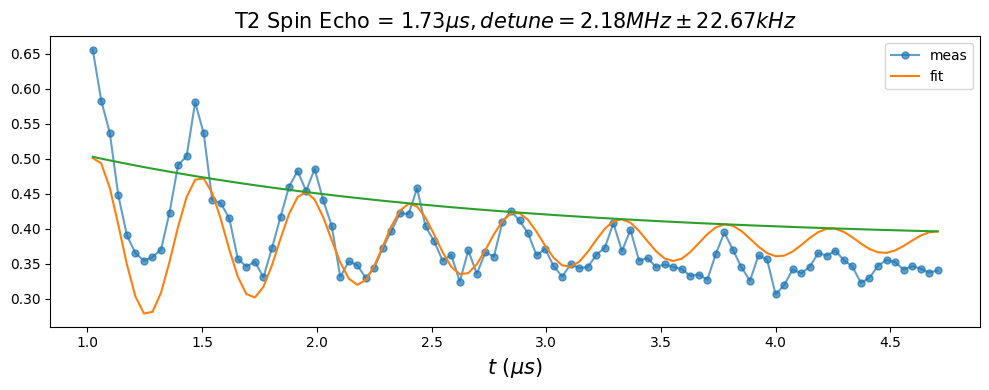

In [59]:
from single_qubit_pyscrip_v1_1.s007_SpinEcho_ge import SpinEcho

run_cfg.update({
    'steps': 100,
    'wait_time': QickSweep1D('waitloop', 0, 4),
    'ramsey_freq': 2})

t2e = SpinEcho(soc, soccfg, run_cfg)
t2e.run(50)
t2e.plot()
t2e.saveLabber(QubitIndex)

In [61]:
# t2e.liveplot(50)

In [ ]:
from single_qubit_pyscrip_v1_1.s008_T1_ge import T1

run_cfg.update({
    'steps': 100,
    'wait_time': QickSweep1D('waitloop', 0, 50),
    'relax_delay': 50
    })

t1= T1(soc, soccfg, run_cfg)
t1.run(50)
t1.plot()
t1.saveLabber(QubitIndex)

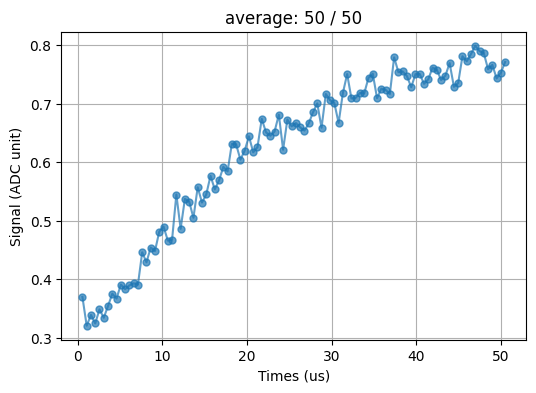

In [71]:
# t1.liveplot(50)

# TEST MODULER

In [192]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from single_qubit_pyscrip_v1_1 import system_cfg
from single_qubit_pyscrip_v1_1.system_tool import select_config_idx
from qick.asm_v2 import QickSpan, QickSweep1D
soc, soccfg = system_cfg.soc, system_cfg.soccfg
config={**system_cfg.hw_cfg,**system_cfg.readout_cfg, **system_cfg.qubit_cfg, **system_cfg.expt_cfg}

qubit_idx=0
run_cfg = select_config_idx(config, qubit_idx)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [130]:
qubit_idx=0
run_cfg = select_config_idx(config, qubit_idx)

# TOF

  0%|          | 0/2000 [00:00<?, ?it/s]

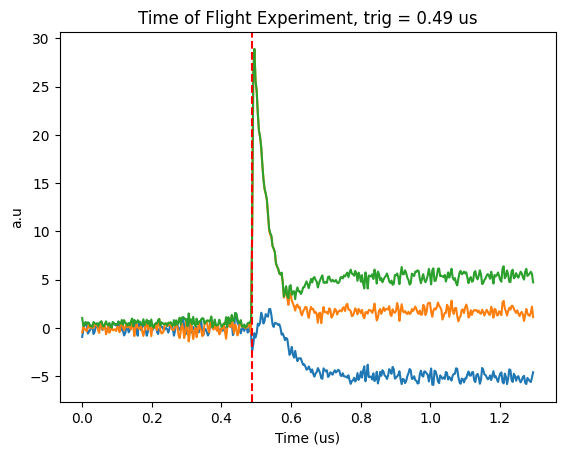

In [121]:
from single_qubit_pyscrip_v1_1.s001_time_of_flight import TOF

run_cfg = select_config_idx(config, qubit_idx)
run_cfg.update({
    'ro_length':1.3,
    'res_legnth':0.2,
    'res_gain_ge':1
})

tof = TOF(soc, soccfg, run_cfg)
tof.run()
tof.plot()

config['trig_time']=0.49

# Resonator OneTone

c:\Users\QEL\Desktop\tprocv2_guidemo-main\single_qubit_pyscrip_v1_1\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': 5.3525, 'Qi': 20372, 'Ql': 728, 'absQc': 754, 'κ(MHz)': 7.36}
Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0528\s002_onetone_Q0_1


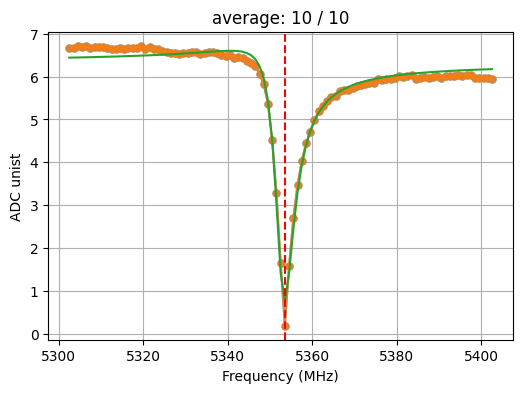

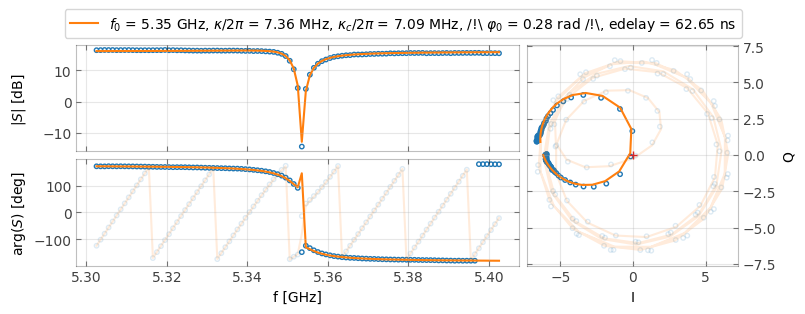

In [ ]:
from single_qubit_pyscrip_v1_1.s002_res_spec_ge import Resonator_onetone

run_cfg = select_config_idx(config, qubit_idx)

START_FREQ = config['res_freq_ge'][qubit_idx]- 50  # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 50   # [MHz]
STEPS = 101
run_cfg.update([('steps', STEPS), 
                ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('res_gain_ge',0.2)
                ])

onetone = Resonator_onetone(soc, soccfg, run_cfg)
# onetone.run(py_avg=10)
onetone.run(py_avg=10, liveplot=True)
result = onetone.plot_circle()
## update value ##
config['res_freq_ge'][qubit_idx] = fres
onetone.saveLabber(qubit_idx, save_sim=True)

  0%|          | 0/10 [00:00<?, ?it/s]

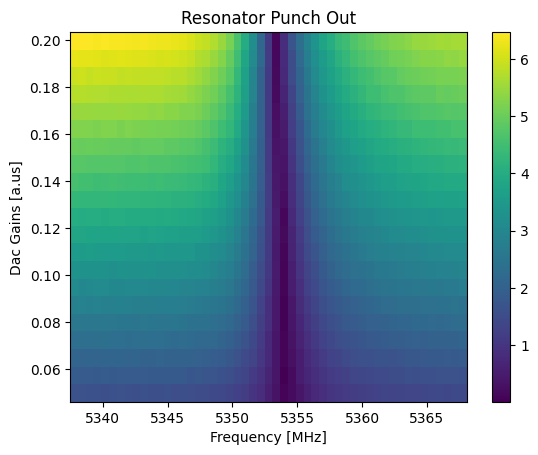

In [ ]:
from single_qubit_pyscrip_v1_1.s002b_res_punchout_ge import SingleToneSpectroscopyPunchout

run_cfg = select_config_idx(config, qubit_idx)

START_FREQ = config['res_freq_ge'][qubit_idx]- 15  # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 15   # [MHz]
STEPS_freq = 51

START_gain = 0.05  # [MHz]
STOP_gain = 0.2  # [MHz]
STEPS_gain = 21
run_cfg.update([('f_steps', STEPS_freq), ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
               ('g_steps', STEPS_gain), ('res_gain_ge', QickSweep1D('gainloop', START_gain, STOP_gain))])
punchout = SingleToneSpectroscopyPunchout(soc, soccfg, run_cfg)
punchout.run(py_avg=10)
punchout.plot()

# Qubit Spectrum ge

Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0528\003_qubit_spec_ge_Q0_3


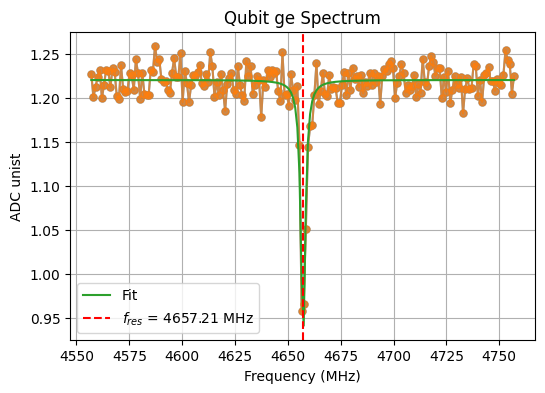

In [220]:
from single_qubit_pyscrip_v1_1.s003_qubit_spec_ge import Qubit_Twotone

run_cfg = select_config_idx(config, qubit_idx)

cemter = 4657
SPAN = 100
START_FREQ = cemter - SPAN # [MHz]
STOP_FREQ = cemter + SPAN  # [MHz]
STEPS = 200
run_cfg.update([('steps', STEPS), 
                ('qubit_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('qmixer_freq',cemter),
                ('qubit_gain_ge', 0.3),
                ('relax_delay',1)
                ])

spectrum_ge = Qubit_Twotone(soc, soccfg, run_cfg)
spectrum_ge.run(20, liveplot=True)
# f_ge = spectrum_ge.plot()
config['qubit_freq_ge'][qubit_idx] = f_ge
config['qmixer_freq'][qubit_idx] = f_ge
spectrum_ge.saveLabber(qubit_idx, save_sim=True)

Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0528\005_power_rabi_ge_Q0_7


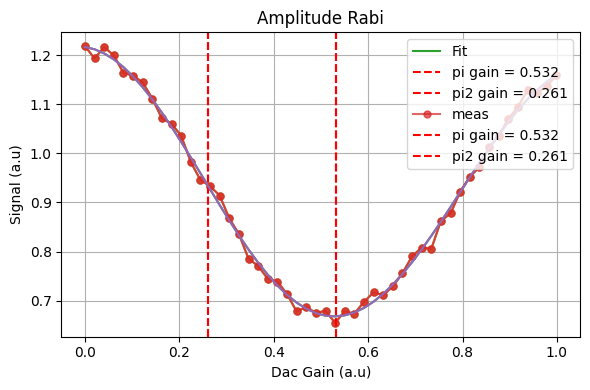

In [216]:
from single_qubit_pyscrip_v1_1.s005_power_rabi_ge import Amp_Rabi


START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 50
config["sigma"][qubit_idx] = 0.3
config['relax_delay'] = 50
run_cfg = select_config_idx(config, qubit_idx)
run_cfg.update([
    ('steps', STEPS), 
    ('qubit_gain_ge',QickSweep1D('gainloop', START_GAIN, STOP_GAIN)),
    ])

prabi = Amp_Rabi(soc, soccfg, run_cfg)
prabi.run(50, liveplot=True)
config['qubit_pi_gain_ge'][qubit_idx], config['qubit_pi2_gain_ge'][qubit_idx] = prabi.plot()
prabi.saveLabber(qubit_idx)

# Ramsey

over detune -0.00838MHz
Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0528\006_Ramsey_ge_Q0_0mA


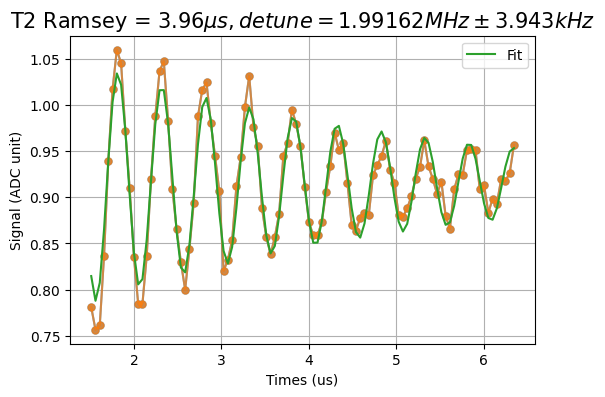

In [219]:
from single_qubit_pyscrip_v1_1.s006_Ramsey_ge import Ramsey

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 5  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('ramsey_freq',2)
    ])

t2r = Ramsey(soc, soccfg, run_cfg)
t2r.run(50, liveplot=True)
# t2r.plot()
config['qubit_freq_ge'][qubit_idx] = t2r.correct_detune()
t2r.saveLabber(qubit_idx, 0, save_sim=True)


Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0528\s007_SpinEcho_ge_Q0_0mA


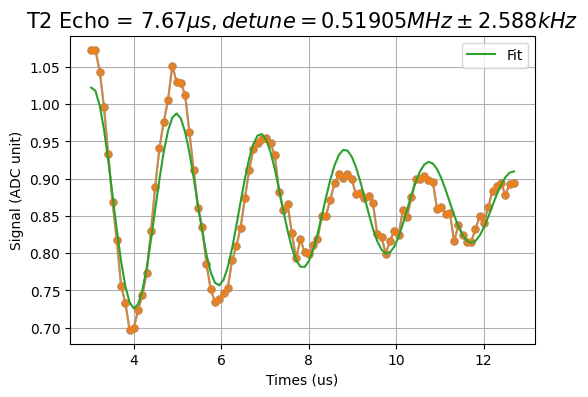

In [225]:
from single_qubit_pyscrip_v1_1.s007_SpinEcho_ge import SpinEcho

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 10  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('ramsey_freq',0.5)
    ])

t2e = SpinEcho(soc, soccfg, run_cfg)
t2e.run(50, liveplot=True)
# t2r.plot()

t2e.saveLabber(qubit_idx, 0, save_sim=True)

# T1

Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0528\s008_T1_ge_Q0_0mA


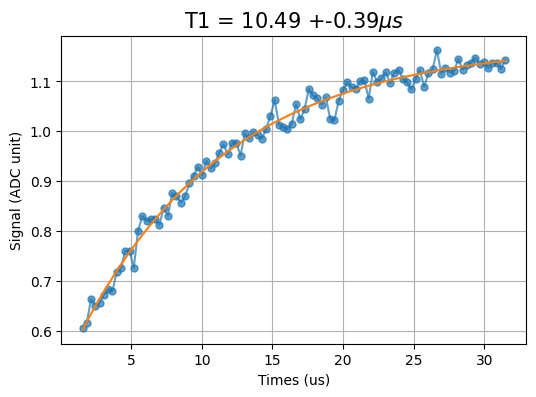

In [231]:
from single_qubit_pyscrip_v1_1.s008_T1_ge import T1

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 30  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('relax_delay', 50)
    ])

t1 = T1(soc, soccfg, run_cfg)
t1.run(20, liveplot=True)


t1.saveLabber(qubit_idx, 0, save_sim=True)